In [1]:
from planning.Occ_Planner import Safe_Planner
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load pre-sampled points + map
Pset = pickle.load(open(f'planning/pre_compute/Pset-4k.pkl', 'rb'))
reachable = pickle.load(open(f'planning/pre_compute/reachable-4k.pkl', 'rb'))
map = np.load('planning/pre_compute/occupancy_grid.npz', allow_pickle=True)['arr_0']
map = np.rot90(map, 2).astype(float)

In [8]:
planner_init_state = [5,0.5,0,1.5]
planner_goal = [6,7,0,0]
sp = Safe_Planner(init_state=planner_init_state, 
                    n_samples=len(Pset),
                    Pset=Pset,
                    reachable=reachable,
                    sensor_dt=0.2,)

In [9]:
res = sp.plan(np.array(planner_init_state), planner_goal, map)
print(res.keys())

Start node is 2522
Search failed
Exploring intermediate goal 4060
No path found
dict_keys(['idx_solution', 'x_waypoints', 'u_waypoints', 'goal_flag'])


In [10]:
sp.world.state_to_pixel(sp.Pset[2531])

array([73, 51])

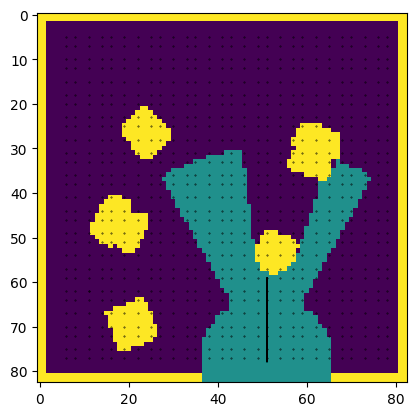

In [11]:
sp.show_connection(res['idx_solution'])

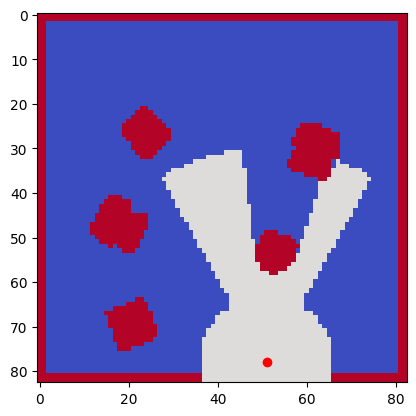

In [12]:
plt.clf()
plt.imshow(sp.world.map_design, cmap='coolwarm')
plt.scatter(sp.world.state_to_pixel(planner_init_state)[1], sp.world.state_to_pixel(planner_init_state)[0], color='red')
if len(res['idx_solution']) > 1:
    x_waypoints = np.vstack(res['x_waypoints'])
    for i in range(len(x_waypoints)-1):
        x1, y1 = sp.world.state_to_pixel(x_waypoints[i])
        x2, y2 = sp.world.state_to_pixel(x_waypoints[i+1])
        plt.plot([y1, y2], [x1, x2], color='green', linewidth=2)
